In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r'C:\Akshay\Data Analytics\Projects Practice\Python EDA\Netflix\netflix1.csv')
print(df.shape)
print(df.info())
print(df.columns)


(8790, 10)
<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8790 non-null   str  
 1   type          8790 non-null   str  
 2   title         8790 non-null   str  
 3   director      8790 non-null   str  
 4   country       8790 non-null   str  
 5   date_added    8790 non-null   str  
 6   release_year  8790 non-null   int64
 7   rating        8790 non-null   str  
 8   duration      8790 non-null   str  
 9   listed_in     8790 non-null   str  
dtypes: int64(1), str(9)
memory usage: 686.8 KB
None
Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='str')


In [6]:
df.head(50)

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
5,s9,TV Show,The Great British Baking Show,Andy Devonshire,United Kingdom,9/24/2021,2021,TV-14,9 Seasons,"British TV Shows, Reality TV"
6,s10,Movie,The Starling,Theodore Melfi,United States,9/24/2021,2021,PG-13,104 min,"Comedies, Dramas"
7,s939,Movie,Motu Patlu in the Game of Zones,Suhas Kadav,India,5/1/2021,2019,TV-Y7,87 min,"Children & Family Movies, Comedies, Music & Mu..."
8,s13,Movie,Je Suis Karl,Christian Schwochow,Germany,9/23/2021,2021,TV-MA,127 min,"Dramas, International Movies"
9,s940,Movie,Motu Patlu in Wonderland,Suhas Kadav,India,5/1/2021,2013,TV-Y7,76 min,"Children & Family Movies, Music & Musicals"


In [15]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [6]:
print(df.duplicated().sum())

0


Text(0.5, 1.0, 'Movies vs TV Shows')

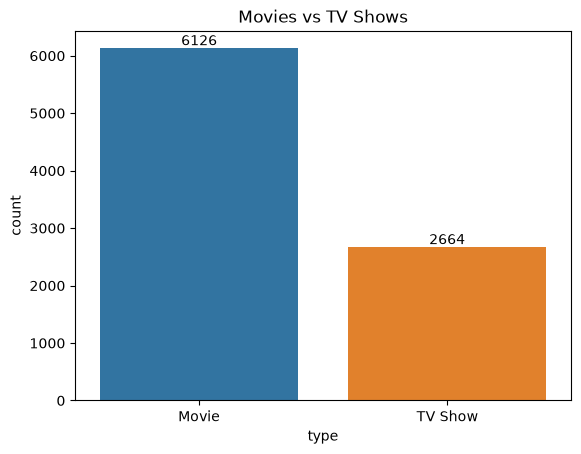

In [37]:
#1. How many Movies and TV Shows are present?
type=sns.countplot(x='type', data=df, hue='type')
for bars in type.containers:
    type.bar_label(bars)
type.set_title("Movies vs TV Shows")    

<function matplotlib.pyplot.show(close=None, block=None)>

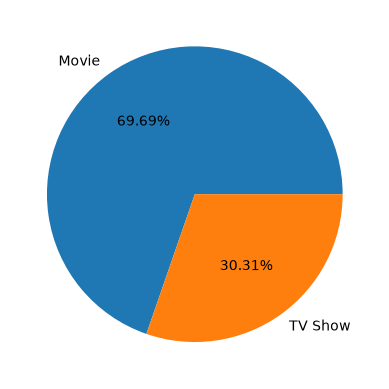

In [31]:
#1. How many Movies and TV Shows are present? 
gb=df.groupby('type').agg({'type':"count"})
plt.pie(gb['type'], labels=gb.index, autopct="%1.2f%%")
plt.show

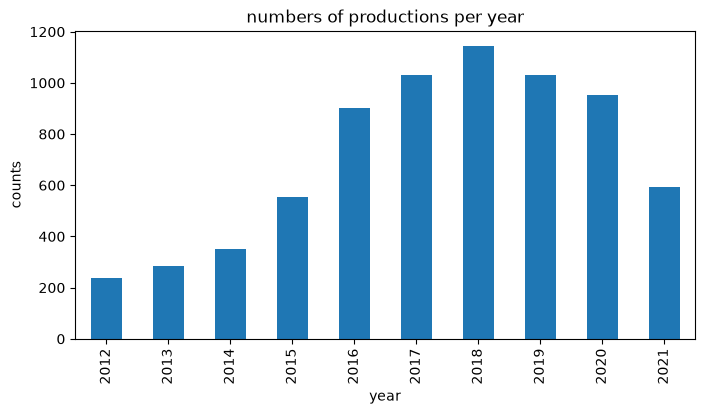

In [25]:
plt.figure(figsize=(8,4))
df['release_year'].value_counts().head(10).sort_index().plot(kind='bar')
plt.title('numbers of productions per year')
plt.xlabel('year')
plt.ylabel('counts')
plt.show()

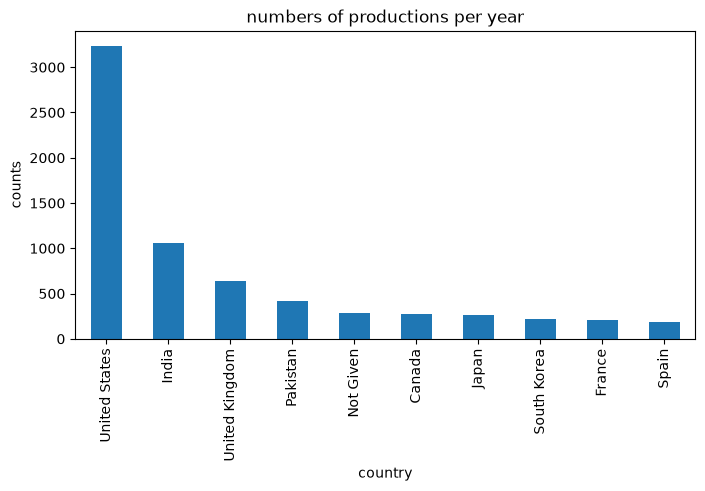

In [17]:
plt.figure(figsize=(8,4))
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries Productions')
plt.xlabel('country')
plt.ylabel('counts')
plt.show()

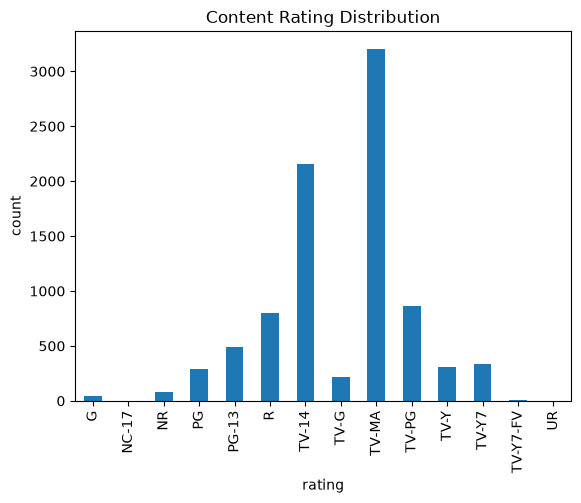

In [30]:
df['rating'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('rating')
plt.ylabel('count')
plt.title('Content Rating Distribution')
plt.show()

<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\DELL\AppData\Local\Temp\ipykernel_18672\4029791002.py:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  movies_df['duration_int'] = movies_df['duration'].str.extract('(\d+)').astype(float)


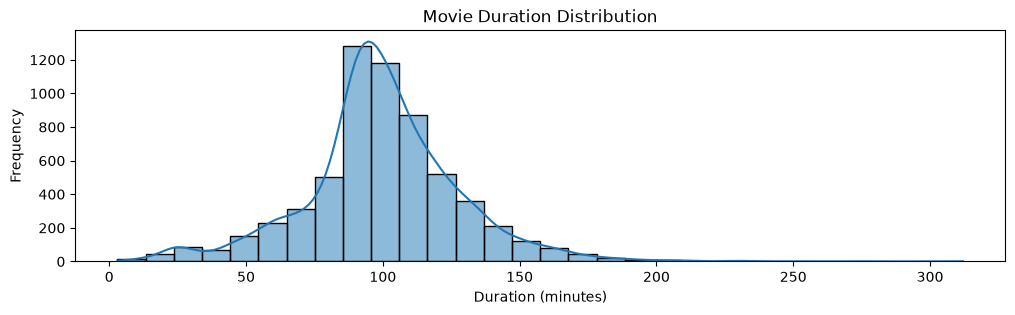

In [32]:
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_int'] = movies_df['duration'].str.extract('(\d+)').astype(float)

plt.figure(figsize=(12,3))
sns.histplot(movies_df['duration_int'], bins=30, kde=True)
plt.title('Movie Duration Distribution')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.show()

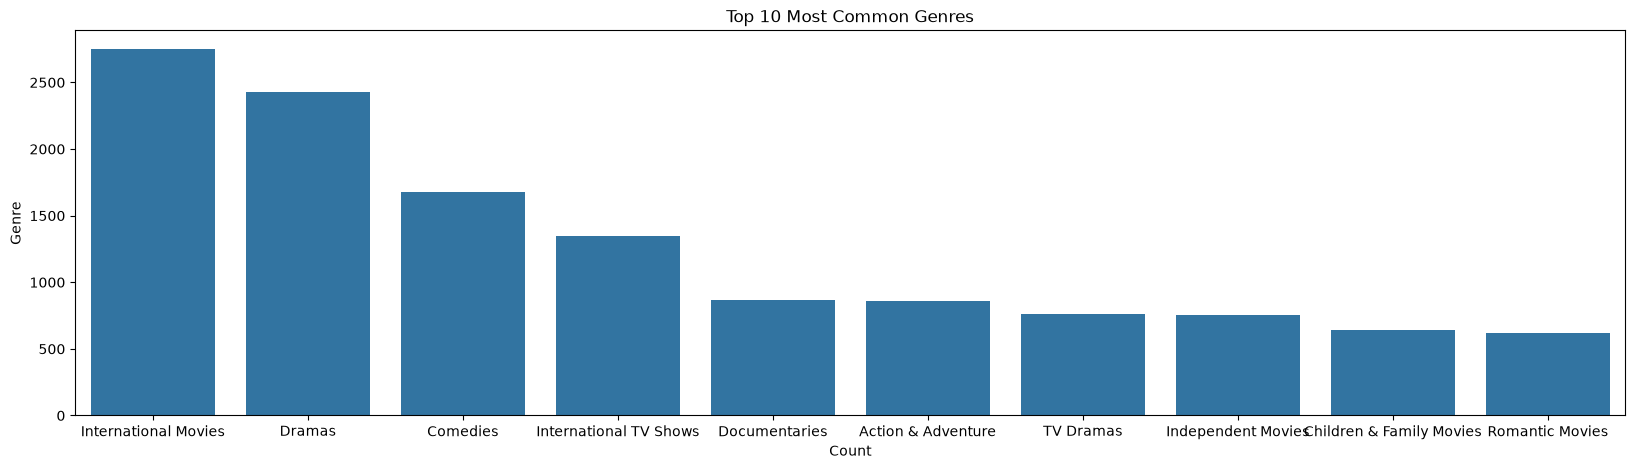

In [36]:
from collections import Counter

all_genres =','.join(df['listed_in'].dropna()).split(',')
genre_count = Counter([genre.strip() for genre in all_genres])
top_genres = genre_count.most_common(10)
label,value = zip(*top_genres)
plt.figure(figsize=(20,5))
sns.barplot(x=list(label), y=list(value))
plt.title('Top 10 Most Common Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

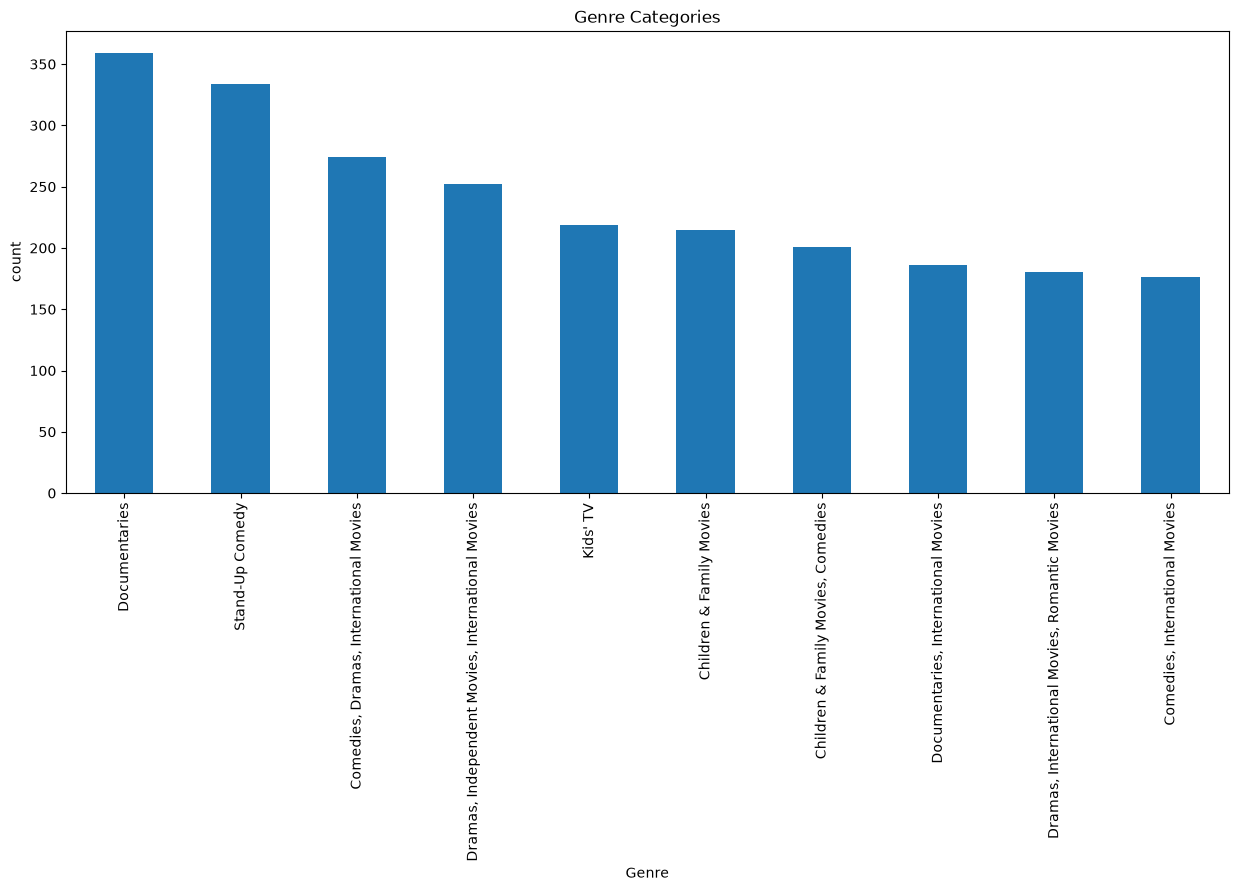

In [20]:
plt.figure(figsize=(15,6))
df['listed_in'].value_counts().iloc[1:11].plot(kind='bar')
plt.xlabel('Genre')
plt.ylabel('count')
plt.title('Genre Categories')
plt.show()

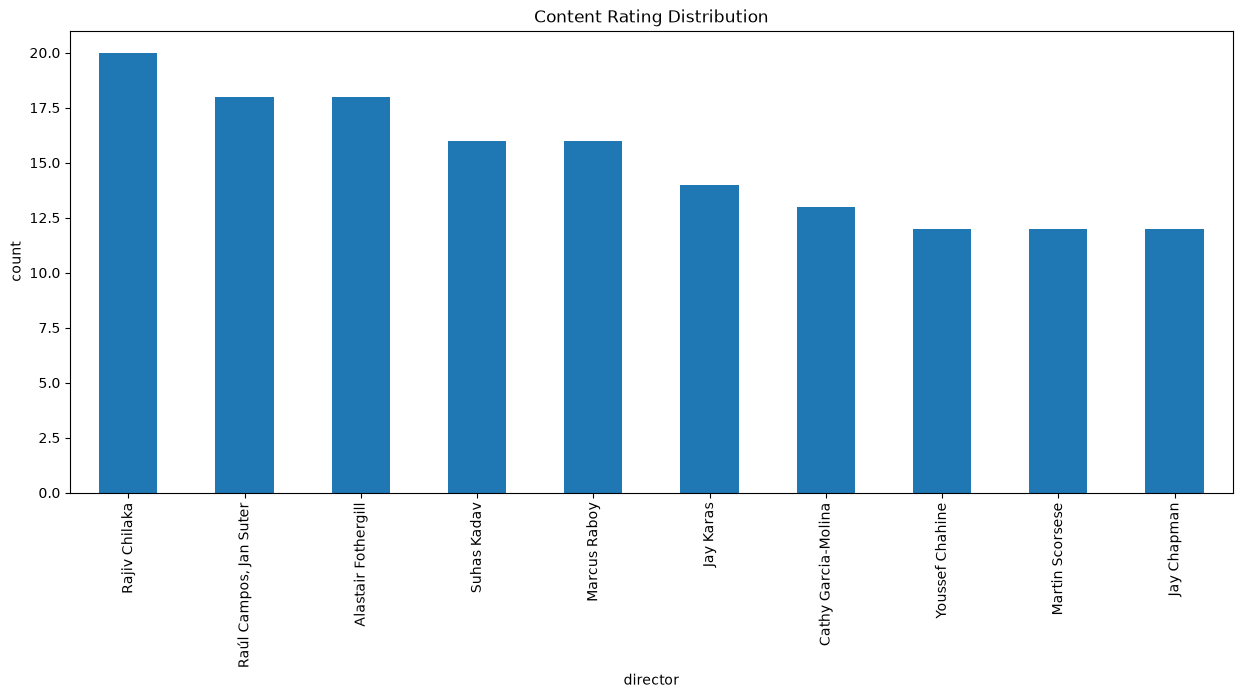

In [24]:
plt.figure(figsize=(15,6))
df['director'].value_counts().iloc[1:11].plot(kind='bar')
plt.xlabel('director')
plt.ylabel('count')
plt.title('Content Rating Distribution')
plt.show()